# Práctica 4 - Modelación No Supervisada

Para esta práctica se aplicó la modelación no supervisada por medio de datos estadistico de la EcoBici, proporcionada por datos de la CDMX.
Los datos abarcan del periodo de febrero de 2010 a abril de 2025, la cantidad de registros usados abarca hasta 10 millones aproximadamente.

## Librerías

In [4]:
#La librería pandas para el manejo y análisis de datos
import pandas as pd

#Se establece el máximo de columnas y filas
pd.set_option("display.max_columns",30)
pd.set_option("display.max_rows",3000)

#Biblitotecas para la creación de graficos
import matplotlib.pyplot as plt
import cufflinks as cf
cf.go_offline()
import numpy as np

### imputacion variables 
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp

#Para unir los archivos csv en uno
import glob
import os

## Combinacion de archivos (DataSet General)

Con ayuda de la librería glob y os, combinamos los archivos descargados de la página oficial con extención csv y lo guardamos en la variable df. Posteriormente definimos las chunk de la memoria para leer todos los datos y hacer el análisis de ellos.

In [ ]:
carpeta = 'C:/Users/HP/Downloads/DataSet'  


In [ ]:
archivos = glob.glob(os.path.join(carpeta, "*.csv"))

In [ ]:
# Lista para almacenar los DataFrames
dataframes = []

for archivo in archivos:
    df_i = pd.read_csv(archivo)
    dataframes.append(df_i)

# Combinar todos en un solo DataFrame
df = pd.concat(dataframes, ignore_index=True)

In [ ]:
###df_combinado.to_excel("DataSetGeneral.csv", index=False)


In [5]:
##df = pd.read_csv("C:/Users/HP/Downloads/2010-02-feb.csv")

## Manejo de cantidades grandes

In [61]:
OUTPUT_FILE = "ecobici_completo.csv"
DRIVE_PATH = "C:/Users/HP/Downloads/DataSet"
TEMP_FOLDER = "ecobici"
CHUNK_SIZE = 100000

# Función de merge
def merge_year_files_fixed():

    year_files = sorted(glob.glob(os.path.join(TEMP_FOLDER, 'merged_*.csv')))

    if not year_files:
        print("No hay archivos temporales. Ejecuta process_year() primero.")
        return 0

    print(f"\nUniendo {len(year_files)} archivos anuales...")
    total_rows = 0

    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
        for i, file in enumerate(year_files):
            try:
                for chunk in pd.read_csv(
                    file,
                    chunksize=CHUNK_SIZE,
                    engine='python',
                    on_bad_lines='warn',
                    dtype={'Genero_Usuario': 'category'}
                ):
                    if not chunk.empty:
                        # Verificación de columnas
                        date_cols = [c for c in ['Fecha_Retiro', 'Fecha_Arribo'] if c in chunk.columns]
                        if date_cols:
                            chunk[date_cols] = chunk[date_cols].apply(pd.to_datetime, errors='coerce')

                        chunk.to_csv(
                            f_out,
                            header=(i == 0 and total_rows == 0),
                            index=False,
                            mode='a'
                        )
                        total_rows += len(chunk)

                print(f"{os.path.basename(file)}: {total_rows:,} filas acumuladas")

            except Exception as e:
                print(f"Error en {file}: {str(e)}")
                continue

    print(f"\nMerge completado. Filas totales: {total_rows:,}")
    return total_rows

# Análisis exploratorio

In [6]:
df.shape

(1057, 9)

In [7]:
def completitud_datos_nulos(df):
    return df.isnull().sum().sort_values(ascending=False) / df.shape[0]
    
df.isnull().sum().sort_values(ascending=False) / df.shape[0]

Genero_Usuario           0.0
Edad_Usuario             0.0
Bici                     0.0
Ciclo_Estacion_Retiro    0.0
Fecha_Retiro             0.0
Hora_Retiro              0.0
Ciclo_Estacion_Arribo    0.0
Fecha_Arribo             0.0
Hora_Arribo              0.0
dtype: float64

## Definición de variables continuas

In [8]:
varc = [x for x in list(df.describe())]

varc

['Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

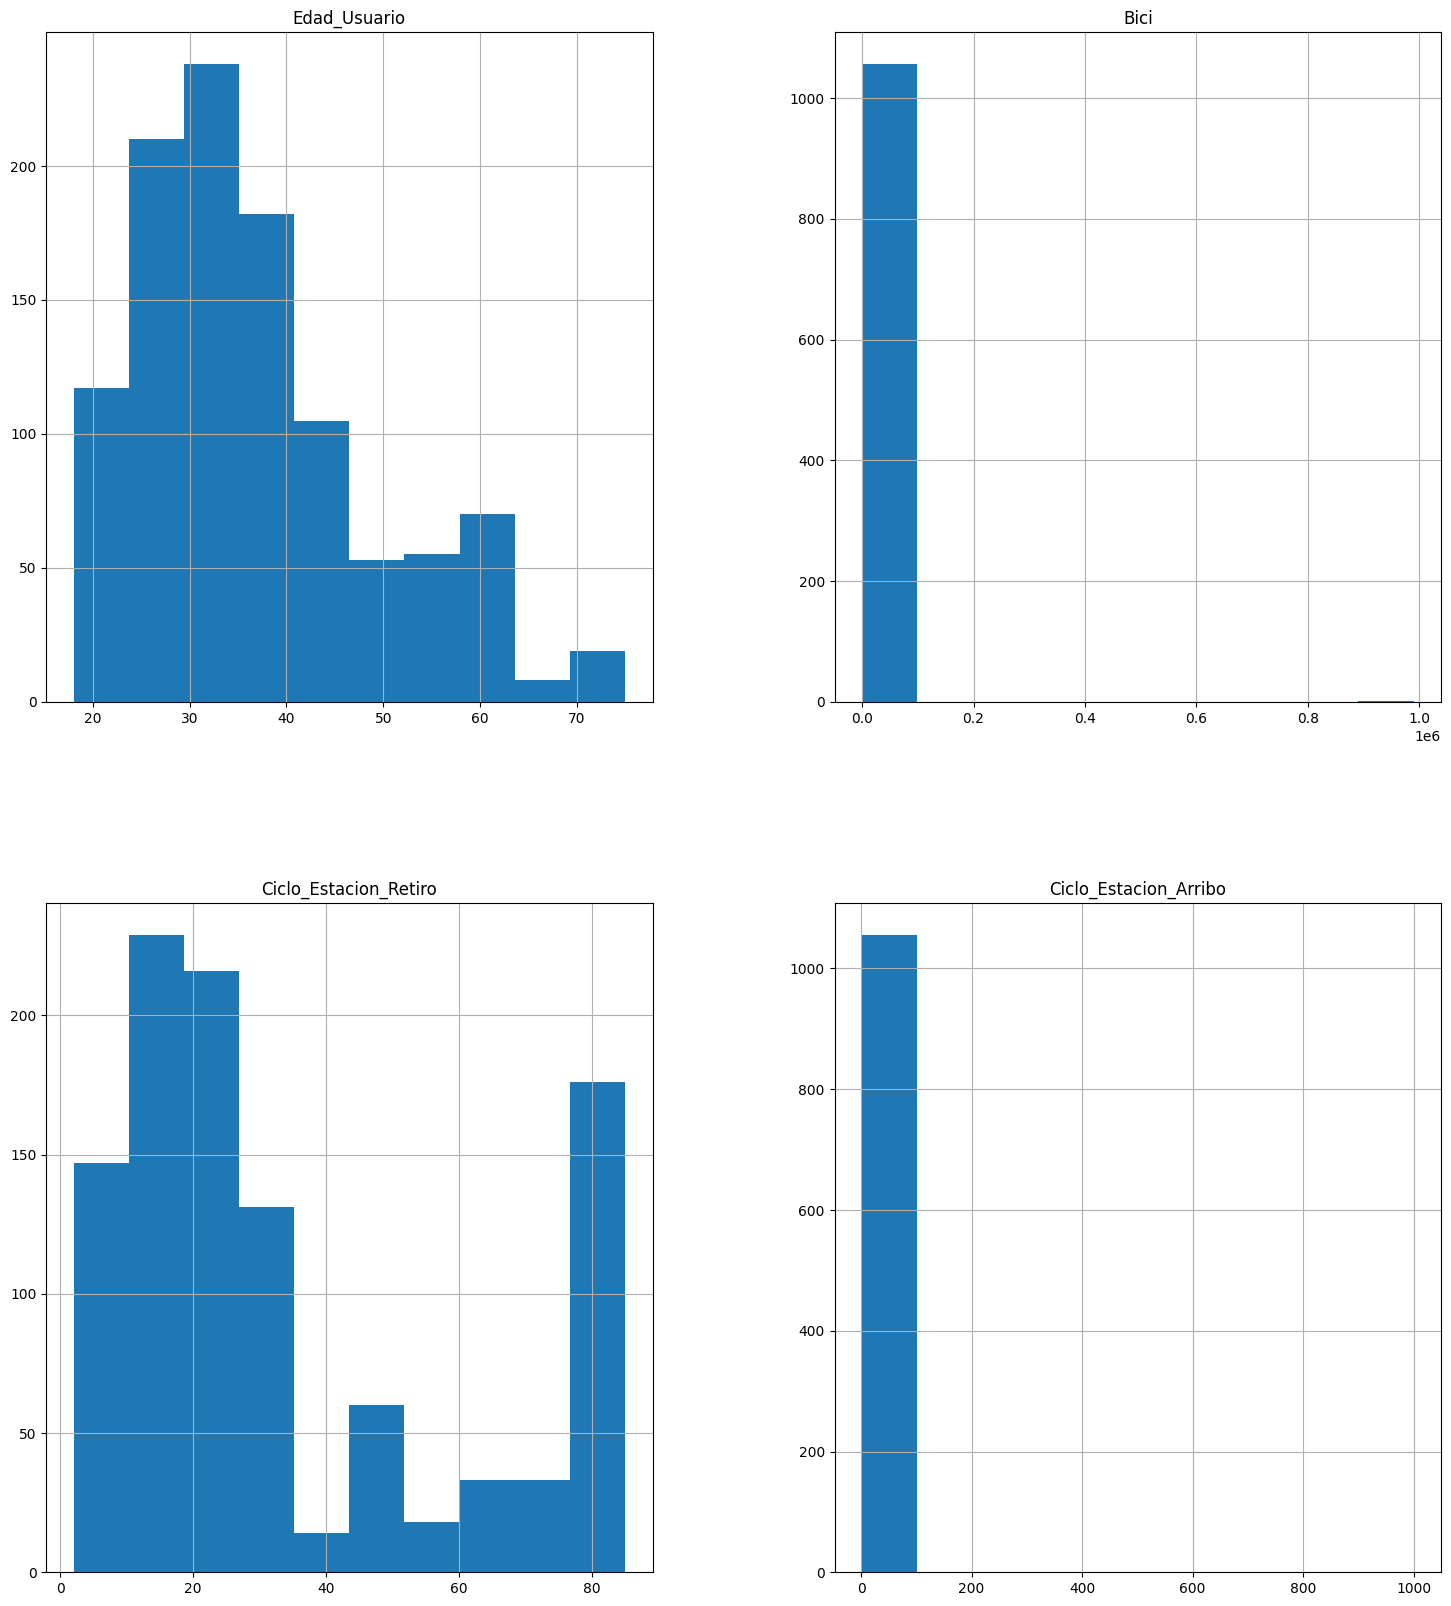

In [9]:
df[varc].hist(figsize=(18,20));

In [12]:
df.shape

(1057, 9)

## Variables Categorias

In [13]:
vard = [y for y in df.columns if y not in varc]

In [18]:
vard

['Genero_Usuario',
 'Fecha_Retiro',
 'Hora_Retiro',
 'Fecha_Arribo',
 'Hora_Arribo']

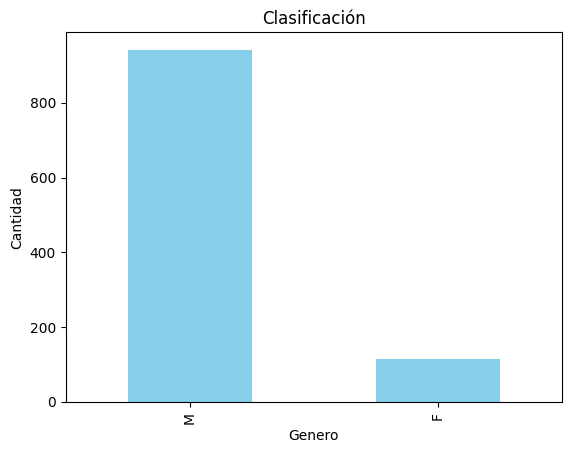

In [24]:
#vard

genero = df['Genero_Usuario'].value_counts()

# Usando matplotlib
genero.plot(kind='bar', color='skyblue')
plt.title('Clasificación')
plt.xlabel('Genero')
plt.ylabel('Cantidad')
plt.show()


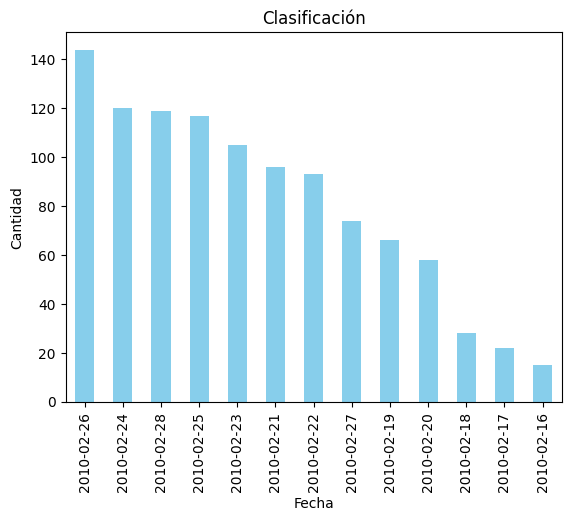

In [23]:
arribo = df['Fecha_Arribo'].value_counts()

# Usando matplotlib
arribo.plot(kind='bar', color='skyblue')
plt.title('Clasificación')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.show()

## Imputación de datos

In [44]:
X = df['Genero_Usuario'].copy()
im = SimpleImputer(strategy="median")
#X.shape
#im.fit_transform(X).shape
print(df)

     Genero_Usuario  Edad_Usuario    Bici  Ciclo_Estacion_Retiro Fecha_Retiro  \
0                 M            28      69                     85   2010-02-16   
1                 M            30      11                     85   2010-02-16   
2                 M            37      43                     85   2010-02-16   
3                 M            37     826                     22   2010-02-16   
4                 M            19     662                     27   2010-02-16   
5                 F            25       8                     85   2010-02-16   
6                 F            31       5                     85   2010-02-16   
7                 M            28     680                     20   2010-02-16   
8                 M            28     618                     20   2010-02-16   
9                 M            32     812                     49   2010-02-16   
10                M            32     711                     66   2010-02-16   
11                M         

In [45]:
def complete_continuous_variables(df,col,strategy='median'):
    X = df[col].copy()
    im = SimpleImputer(strategy=strategy)
    Xi = pd.DataFrame(im.fit_transform(X),columns=col)
    l_ks = []
    for v in col:
        l_ks.append([v,ks_2samp(X[v].dropna(),Xi[v]).statistic])
    ks = pd.DataFrame(l_ks,columns=['feat','ks'])
    #print(ks)
    print((ks.ks>=0.1).sum())
    df[col] = im.transform(df[col].copy())
    return df
varc

['Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

In [23]:
df

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_Estacion_Arribo,Fecha_Arribo,Hora_Arribo
0,M,28.0,69.0,NaN,2010-02-16,12:42:32.160000,NaN,2010-02-16,12:45:37.427000
1,M,30.0,11.0,NaN,2010-02-16,12:53:29.950000,26.0,2010-02-16,13:22:23.737000
2,M,37.0,43.0,NaN,2010-02-16,13:21:46.440000,13.0,2010-02-16,13:49:47.190000
3,M,37.0,826.0,22.0,2010-02-16,14:06:40.480000,NaN,2010-02-16,14:23:13.567000
4,M,NaN,662.0,27.0,2010-02-16,15:31:15.603000,74.0,2010-02-16,16:29:17.150000
5,F,25.0,NaN,NaN,2010-02-16,16:31:53.100000,20.0,2010-02-16,16:49:26.723000
6,F,31.0,NaN,NaN,2010-02-16,16:33:25.400000,20.0,2010-02-16,16:49:28.973000
7,M,28.0,680.0,20.0,2010-02-16,17:06:18.487000,25.0,2010-02-16,17:22:56.547000
8,M,28.0,618.0,20.0,2010-02-16,17:30:14.333000,17.0,2010-02-16,17:48:24.583000
9,M,32.0,812.0,49.0,2010-02-16,18:10:21.337000,72.0,2010-02-16,18:16:21.213000


In [46]:
df = df.dropna().reset_index(drop=True)

## Modelación no supervisada

In [47]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
#X = data[best].sample(frac=0.1).reset_index(drop=True).copy()
X = df[varc].reset_index(drop=True).copy()
X_perfil = X
scaler = StandardScaler()
scaler.fit(X)
Xs = pd.DataFrame(scaler.transform(X), columns=X.columns)
pca = PCA(n_components=3)
mds = MDS(n_components=3, n_jobs=.1)
tsne= TSNE()
pca.fit(Xs)

PCA(n_components=3)

In [49]:
pca.explained_variance_ratio_.cumsum()

array([0.30235121, 0.56016358, 0.79326763])

In [50]:
Xp = pd.DataFrame(pca.transform(Xs), columns=["p1","p2","p3"])

## Definición de Cluster

In [57]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
lst_in = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xs)
    lst_in.append(km.inertia_)

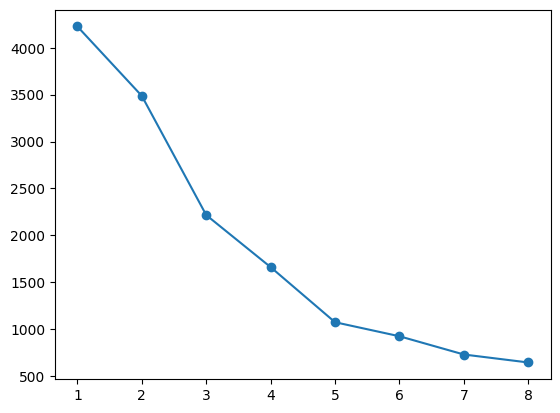

In [58]:
plt.plot(range(1,9),lst_in,marker='o');

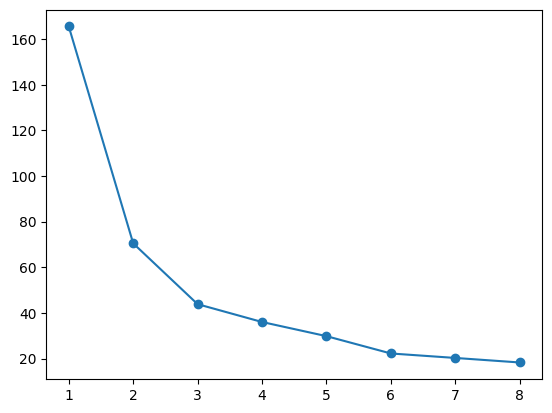

In [59]:
minmax = MinMaxScaler()
minmax.fit(X)
Xmm = pd.DataFrame(minmax.transform(X), columns=X.columns)
lst = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xmm)
    lst.append(km.inertia_)
plt.plot(range(1,9),lst,marker='o');

In [60]:
cl_xp = GaussianMixture(n_components=3, max_iter=2000)
#cl_xt = GaussianMixture(n_components=3, max_iter=2000)
cl_xp.fit(Xp)
#cl_xt.fit(Xt)
Xp["cl"] = cl_xp.predict(Xp)
#Xt["cl"] = cl_xt.predict(Xt)
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()

print("PCA")
Xp.cl.value_counts(True)


PCA


cl
0    0.573321
2    0.425733
1    0.000946
Name: proportion, dtype: float64